# punto 2

In [2]:
# Importar bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
# Use seaborn's API to set the style (more robust across matplotlib versions)
sns.set_style('whitegrid')
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 6]


Carga el dataset Bank Marketing desde el repositorio UCI (usando `fetch_ucirepo`) y asegura que las características estén en un DataFrame de pandas; también muestra información básica (shape, columnas y tipos).


In [3]:
# Cargar dataset
bank = fetch_ucirepo(id=222)
X = bank.data.features
y = bank.data.targets

# Asegurar que X sea DataFrame
if not isinstance(X, pd.DataFrame):
    try:
        cols = bank.data.feature_names
    except:
        cols = None
    X = pd.DataFrame(X, columns=cols)

# Mostrar información inicial
print("Shape:", X.shape)
print("\nColumnas:", X.columns.tolist())
print("\nTipos de datos:")
print(X.dtypes)

Shape: (45211, 16)

Columnas: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

Tipos de datos:
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
dtype: object



Realiza el preprocesamiento: one-hot encoding para categóricas, eliminación de `duration` si existe, y estandarización de características numéricas con `StandardScaler`.

El clustering depende fuertemente de la representación de las características y de la escala; estas transformaciones evitan que variables categóricas o escalas distintas distorsionen las distancias usadas por los algoritmos.

In [4]:
# Preprocesamiento
# 1. One-hot encoding para variables categóricas
X_encoded = pd.get_dummies(X, drop_first=False)

# 2. Eliminar 'duration' si existe (no relevante para clustering)
if 'duration' in X_encoded.columns:
    X_encoded = X_encoded.drop('duration', axis=1)

# 3. Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Shape después de preprocesamiento:", X_scaled.shape)
print("\nPrimeras 5 filas (escaladas):")
print(pd.DataFrame(X_scaled[:5, :5], columns=X_encoded.columns[:5]))

Shape después de preprocesamiento: (45211, 46)

Primeras 5 filas (escaladas):
        age   balance  day_of_week  campaign     pdays
0  1.606965  0.256419    -1.298476 -0.569351 -0.411453
1  0.288529 -0.437895    -1.298476 -0.569351 -0.411453
2 -0.747384 -0.446762    -1.298476 -0.569351 -0.411453
3  0.571051  0.047205    -1.298476 -0.569351 -0.411453
4 -0.747384 -0.447091    -1.298476 -0.569351 -0.411453



Define el criterio J4 y una función auxiliar para evaluar clustering en un rango de números de clusters. J4 compara la dispersión entre clusters con la dispersión interna.


In [5]:
# Implementación del criterio J4
def calculate_j4(X, labels):
    """
    Calcula el criterio J4 para un clustering dado.
    J4 = ratio de la suma de dispersiones entre clusters y dentro de clusters
    Mayor J4 indica mejor clustering.
    """
    # Obtener centroides y asignaciones únicas
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    if n_clusters <= 1:
        return 0
    
    centroids = np.array([X[labels == k].mean(axis=0) for k in unique_labels])
    global_centroid = X.mean(axis=0)
    
    # Calcular dispersión dentro de clusters (within)
    within_scatter = 0
    for k in unique_labels:
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            within_scatter += np.sum((cluster_points - centroids[k == unique_labels]) ** 2)
    
    # Calcular dispersión entre clusters (between)
    between_scatter = np.sum(len(X[labels == k]) * 
                           np.sum((centroid - global_centroid) ** 2) 
                           for k, centroid in zip(unique_labels, centroids))
    
    # Evitar división por cero
    if within_scatter == 0:
        return float('inf')
    
    return between_scatter / within_scatter

# Función para evaluar diferentes números de clusters
def evaluate_clustering(X, linkage_matrix, n_clusters_range):
    j4_scores = []
    for n in n_clusters_range:
        labels = fcluster(linkage_matrix, n, criterion='maxclust')
        j4 = calculate_j4(X, labels)
        j4_scores.append(j4)
    return j4_scores


Ejecuta el clustering jerárquico con varios métodos de linkage sobre una submuestra, dibuja dendrogramas y evalúa J4 para distintos números de clusters.



Usando muestra de 2000 de 45211 instancias para clustering jerárquico (rápido).


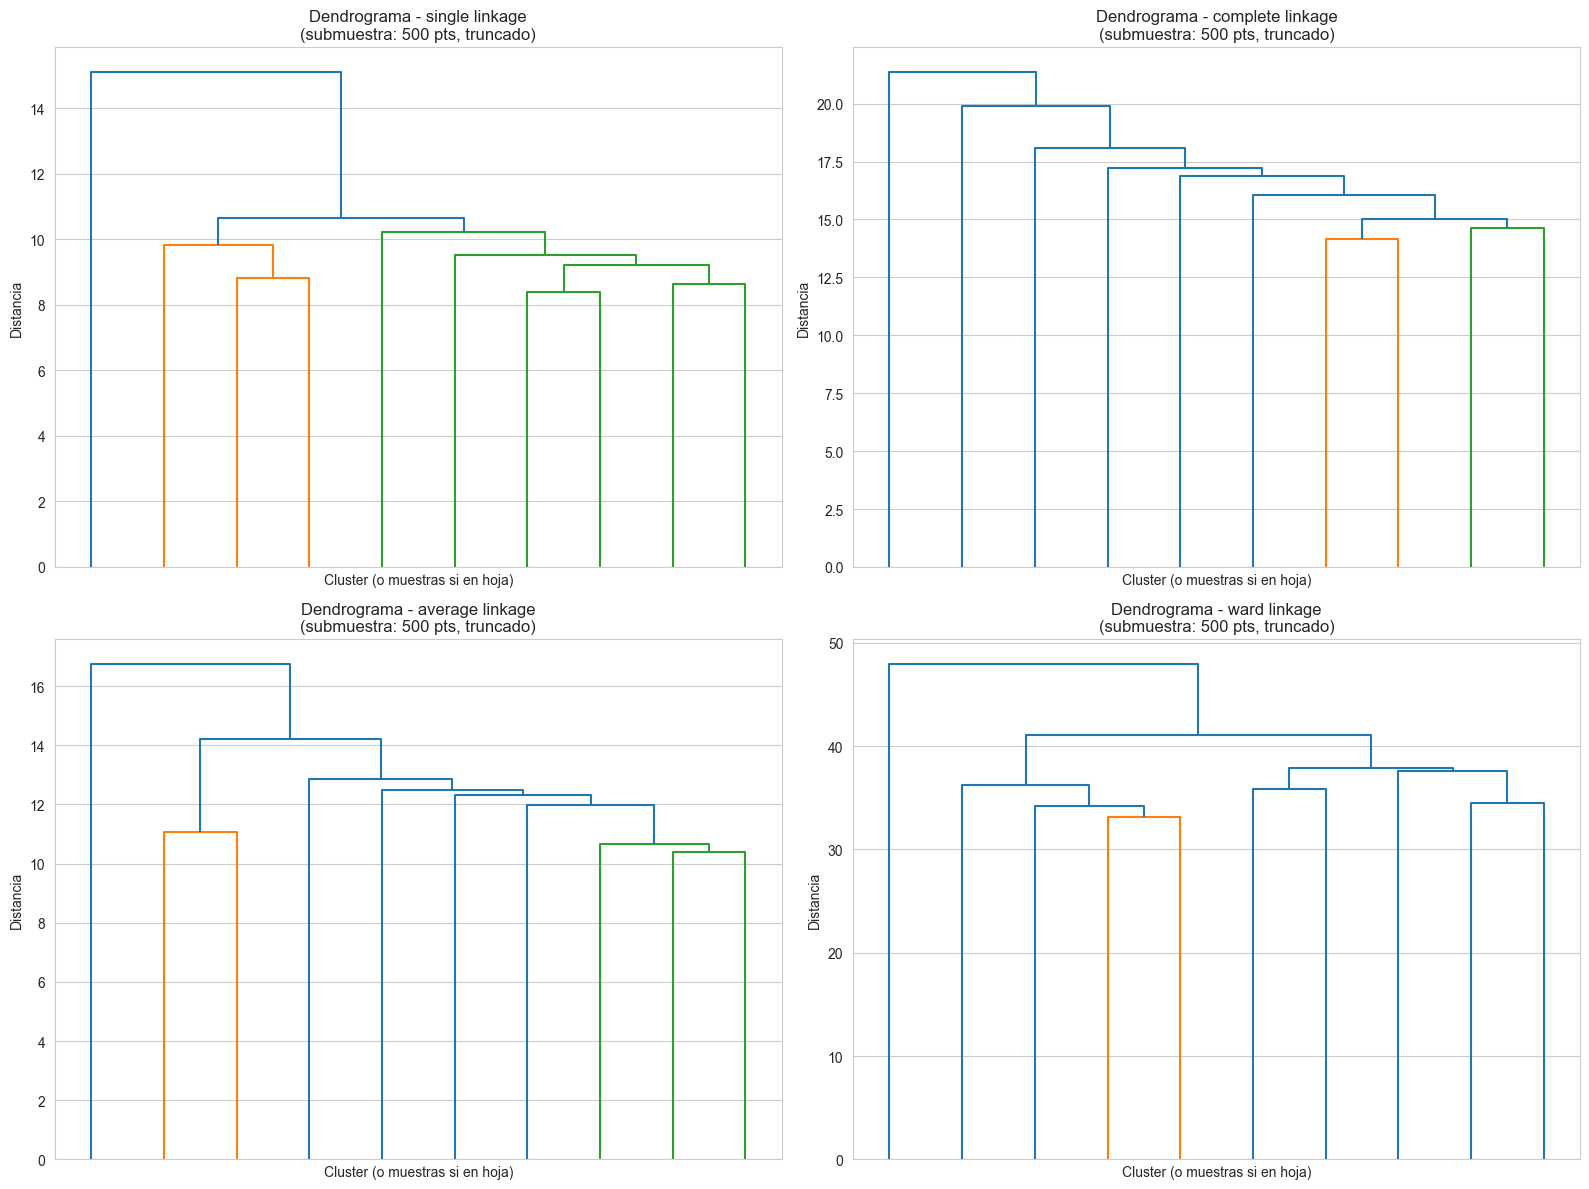

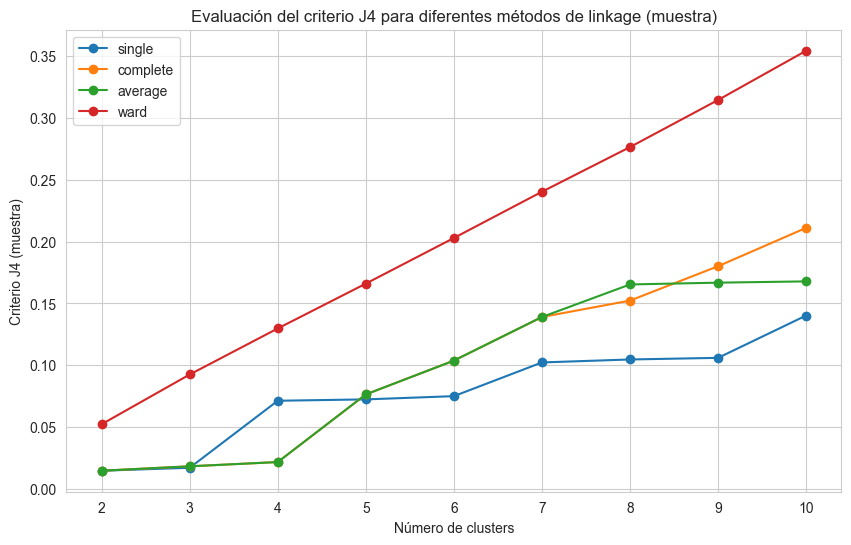

Mejor método (muestra): ward
Número óptimo de clusters (muestra): 10

Valores J4 máximos para cada método (muestra):
single: 0.1403
complete: 0.2112
average: 0.1679
ward: 0.3544

Nota: dendrogramas mostrados con submuestra de 500 pts y truncado para legibilidad.
Evaluación J4 realizada sobre muestra de 2000 pts.
Para validación más precisa: (1) aumentar `max_sample`, (2) usar K-means sobre el dataset completo,
o (3) usar técnicas de clustering aproximado/escalable.


In [6]:
# Aplicar clustering jerárquico con diferentes métodos de linkage (muestra para acelerar)
methods = ['single', 'complete', 'average', 'ward']
linkage_matrices = {}

# Para datasets grandes el clustering jerárquico es muy costoso (O(n^2)).
# Usaremos una submuestra representativa para los dendrogramas y para la evaluación J4.
n_samples = X_scaled.shape[0]
max_sample = 2000  # ajuste: 2000 es bueno para visualización y razonable en tiempo/espacio
sample_size = min(max_sample, n_samples)

rng = np.random.default_rng(42)
sample_idx = rng.choice(n_samples, size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

print(f"Usando muestra de {sample_size} de {n_samples} instancias para clustering jerárquico (rápido).")

# Calcular matriz de distancia sobre la muestra
from scipy.spatial.distance import pdist
sample_distances = pdist(X_sample)

# Para dendrogramas: usar una submuestra aún más pequeña (500) para mejor visualización
# Mantener X_sample completa para J4
dendro_sample_size = min(500, sample_size)
dendro_idx = rng.choice(sample_size, size=dendro_sample_size, replace=False)
X_dendro = X_sample[dendro_idx]
dendro_distances = pdist(X_dendro)

# Crear figura para los dendrogramas (tamaño más pequeño para mejor legibilidad)
plt.figure(figsize=(16, 12))

for i, method in enumerate(methods, 1):
    # Calcular linkage: usar muestra pequeña para dendrogramas
    if method == 'ward':
        dendro_linkage = linkage(X_dendro, method=method)
        # También calcular para X_sample completa para J4
        linkage_matrices[method] = linkage(X_sample, method=method)
    else:
        dendro_linkage = linkage(dendro_distances, method=method)
        # También calcular para X_sample completa para J4
        linkage_matrices[method] = linkage(sample_distances, method=method)
    
    # Plotear dendrograma truncado (usando la submuestra pequeña) con mejor visualización
    plt.subplot(2, 2, i)
    dendrogram(dendro_linkage, no_labels=True, truncate_mode='lastp', p=10)
    plt.title(f'Dendrograma - {method} linkage\n(submuestra: {dendro_sample_size} pts, truncado)')
    plt.xlabel('Cluster (o muestras si en hoja)')
    plt.ylabel('Distancia')

plt.tight_layout()
plt.show()

# Evaluar diferentes números de clusters para cada método usando la muestra completa
n_clusters_range = range(2, 11)
j4_scores = {}

for method in methods:
    j4_scores[method] = evaluate_clustering(X_sample, linkage_matrices[method], n_clusters_range)

# Visualizar resultados J4 (muestra)
plt.figure(figsize=(10, 6))
for method in methods:
    plt.plot(list(n_clusters_range), j4_scores[method], marker='o', label=method)

plt.xlabel('Número de clusters')
plt.ylabel('Criterio J4 (muestra)')
plt.title('Evaluación del criterio J4 para diferentes métodos de linkage (muestra)')
plt.legend()
plt.grid(True)
plt.show()

# Encontrar mejor método y número de clusters (según la muestra)
best_scores = {method: max(scores) for method, scores in j4_scores.items()}
best_method = max(best_scores.items(), key=lambda x: x[1])[0]
best_n_clusters = list(n_clusters_range)[np.argmax(j4_scores[best_method])]

print(f"Mejor método (muestra): {best_method}")
print(f"Número óptimo de clusters (muestra): {best_n_clusters}")
print("\nValores J4 máximos para cada método (muestra):")
for method, score in best_scores.items():
    print(f"{method}: {score:.4f}")

# Nota y paso adicional recomendado
print('\nNota: dendrogramas mostrados con submuestra de 500 pts y truncado para legibilidad.')
print('Evaluación J4 realizada sobre muestra de', sample_size, 'pts.')
print('Para validación más precisa: (1) aumentar `max_sample`, (2) usar K-means sobre el dataset completo,')
print('o (3) usar técnicas de clustering aproximado/escalable.')


Aquí se añade la sección de K‑means: calcula la inercia, J4 y silhouette para un rango de k, selecciona el mejor k según J4 y visualiza los clusters proyectados con PCA.


## Métodos basados en centroides: Algoritmo K‑medias

El algoritmo k‑medias está basado en la minimización de la distancia intra‑grupo para cada una de las agrupaciones. En su forma más simple, el algoritmo consta de tres pasos:

1. **Inicialización**: una vez escogido el número de grupos, k, se establecen k centroides en el espacio de los datos, por ejemplo, escogiéndolos aleatoriamente.
2. **Asignación objetos a los centroides**: cada objeto de los datos es asignado a su centroide más cercano.
3. **Actualización centroides**: se actualiza la posición del centroide de cada grupo tomando como nuevo centroide la posición del promedio de los objetos pertenecientes a dicho grupo.

En esta sección aplicaremos K‑means sobre las mismas características preprocesadas y usaremos varias visualizaciones útiles para la toma de decisión: curva de codo (inercia), criterio J4, silhouette y una proyección PCA en 2D de los clusters para facilitar la interpretación visual.


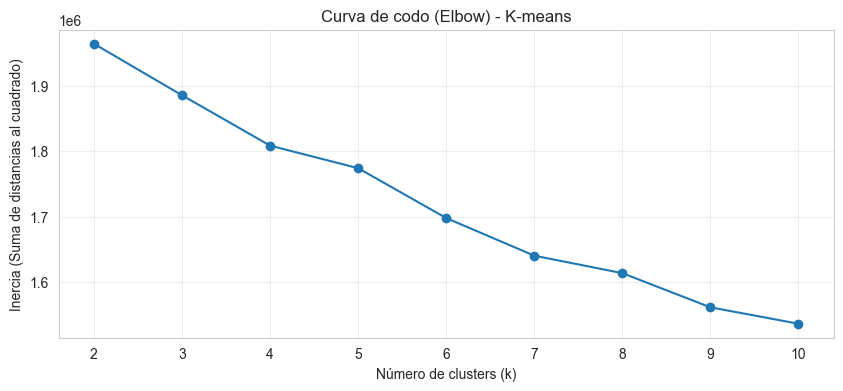

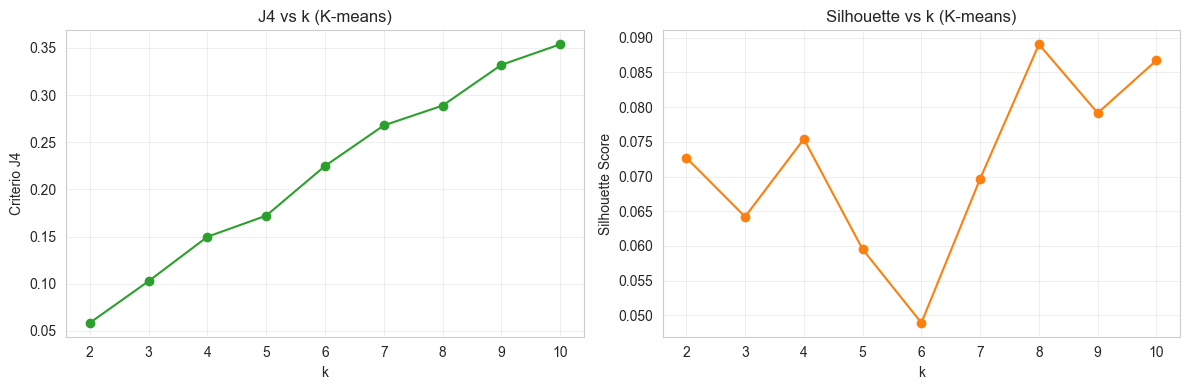

Mejor k según J4: 10 (J4=0.3538, Silhouette=0.0867)


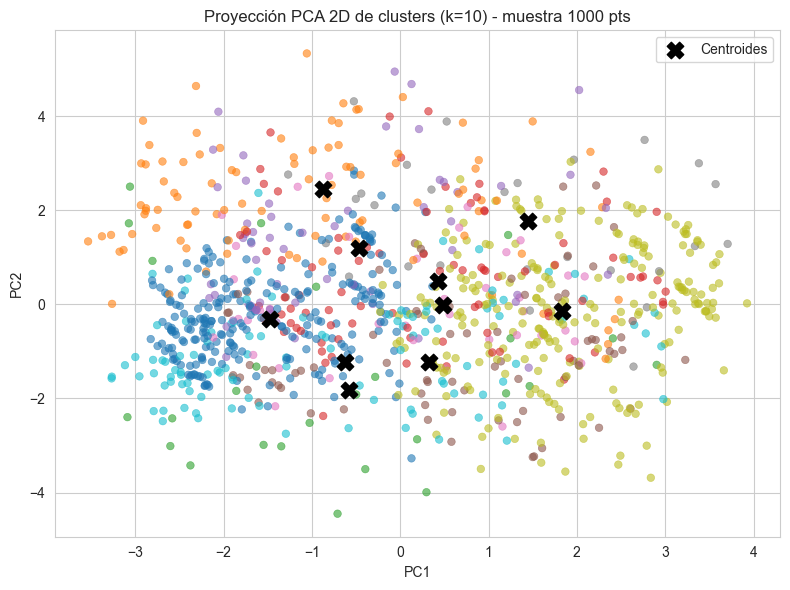

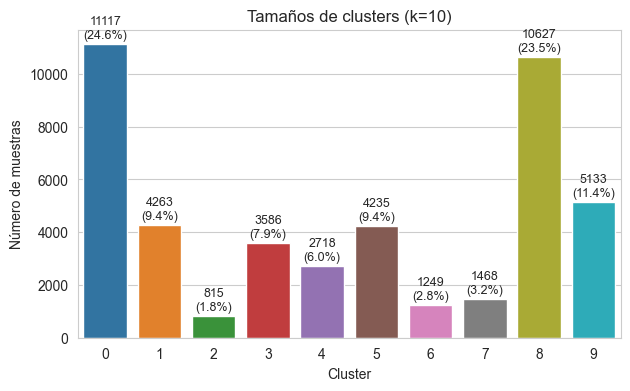

In [9]:
# K-means: visualizaciones mejoradas (elbow / J4 / Silhouette / PCA 2D / tamaños)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns

# Asegurar X_scaled está disponible
try:
    Xs = X_scaled
except NameError:
    X_encoded = pd.get_dummies(X, drop_first=False)
    if 'duration' in X_encoded.columns:
        X_encoded = X_encoded.drop('duration', axis=1)
    Xs = StandardScaler().fit_transform(X_encoded)

# Parámetros
k_range = list(range(2, 11))
inertias = []
j4_kmeans = []
sil_kmeans = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xs)
    inertias.append(km.inertia_)
    j4_kmeans.append(calculate_j4(Xs, labels))
    sil_kmeans.append(silhouette_score(Xs, labels))

# 1) Elbow plot (Inercia)
plt.figure(figsize=(10,4))
plt.plot(k_range, inertias, '-o', color='tab:blue')
plt.xticks(k_range)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Suma de distancias al cuadrado)')
plt.title('Curva de codo (Elbow) - K-means')
plt.grid(alpha=0.3)
plt.show()

# 2) J4 y Silhouette (comparativa)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(k_range, j4_kmeans, '-o', color='tab:green')
plt.xticks(k_range)
plt.xlabel('k')
plt.ylabel('Criterio J4')
plt.title('J4 vs k (K-means)')
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(k_range, sil_kmeans, '-o', color='tab:orange')
plt.xticks(k_range)
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette vs k (K-means)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Seleccionar mejor k según J4 (como referencia)
best_k_idx = int(np.argmax(j4_kmeans))
best_k = k_range[best_k_idx]
print(f"Mejor k según J4: {best_k} (J4={j4_kmeans[best_k_idx]:.4f}, Silhouette={sil_kmeans[best_k_idx]:.4f})")

# 3) Ajuste final con el mejor k y visualización PCA 2D (submuestreo para claridad)
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_best = km_best.fit_predict(Xs)
centroids = km_best.cluster_centers_

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(Xs)
centroids_pca = pca.transform(centroids)

# Submuestreo para la visualización: muestra hasta 1000 puntos para mantener legibilidad
plot_n = min(1000, X_pca.shape[0])
rng = np.random.default_rng(42)
plot_idx = rng.choice(X_pca.shape[0], size=plot_n, replace=False)

plt.figure(figsize=(8,6))
# puntos semitransparentes y sin borde para evitar sobreplotting
sns.scatterplot(x=X_pca[plot_idx,0], y=X_pca[plot_idx,1], hue=labels_best[plot_idx],
                palette='tab10', s=30, alpha=0.6, edgecolor=None, legend=False)
# centroides en marcador destacado
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], c='black', s=140, marker='X', label='Centroides')

plt.title(f'Proyección PCA 2D de clusters (k={best_k}) - muestra {plot_n} pts')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 4) Tamaños de clusters (valores absolutos y porcentaje)
plt.figure(figsize=(7,4))
counts = np.bincount(labels_best)
percent = 100.0 * counts / counts.sum()
ax = sns.barplot(x=list(range(best_k)), y=counts, palette='tab10')
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + max(counts)*0.01, f"{int(height)}\n({percent[i]:.1f}%)",
            ha='center', va='bottom', fontsize=9)
plt.xlabel('Cluster')
plt.ylabel('Número de muestras')
plt.title(f'Tamaños de clusters (k={best_k})')
plt.show()

# 5) Guardar resultados en variables para posteriores análisis
kmeans_results = {
    'k_range': k_range,
    'inertias': inertias,
    'j4_kmeans': j4_kmeans,
    'sil_kmeans': sil_kmeans,
    'best_k': best_k,
    'labels_best': labels_best,
    'centroids': centroids
}
